We focus on **Bibliographic Coupling (BC)**: A and B are similar because *they both cite* the same paper C.

In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from itertools import combinations
from datetime import datetime
from pathlib import Path

In [2]:
BASE_DIR = Path().resolve().parent.parent

IN_GRAPH_DIR = BASE_DIR / "data" / "graph" / "A_graph_creation"
OUT_GRAPH_DIR = BASE_DIR / "data" / "graph"

with open(IN_GRAPH_DIR / "A_source_graph.gpickle", "rb") as f:
    G = pickle.load(f)

In [3]:
is_unipi = lambda n: G.nodes[n].get("is_unipi", False)

ext_to_unipi_edges = [(u, v) for u, v in G.edges() if not is_unipi(u) and is_unipi(v)]
ext_to_ext_edges   = [(u, v) for u, v in G.edges() if not is_unipi(u) and not is_unipi(v)]
G.remove_edges_from(ext_to_unipi_edges + ext_to_ext_edges)

unipi_set = {n for n in G.nodes() if is_unipi(n)}

isolated     = list(nx.isolates(G))
ext_orphaned = [n for n in G.nodes()
                if not is_unipi(n)
                and not (set(G.successors(n)) | set(G.predecessors(n))) & unipi_set]

G.remove_nodes_from(isolated + ext_orphaned)

unipi_nodes = [n for n in G.nodes() if is_unipi(n)]
ext_nodes   = [n for n in G.nodes() if not is_unipi(n)]

edge_types = {
    "UNIPI → UNIPI"   : sum(1 for u, v in G.edges() if is_unipi(u) and is_unipi(v)),
    "UNIPI → External": sum(1 for u, v in G.edges() if is_unipi(u) and not is_unipi(v)),
    "External → UNIPI": sum(1 for u, v in G.edges() if not is_unipi(u) and is_unipi(v)),
    "Ext → Ext"       : sum(1 for u, v in G.edges() if not is_unipi(u) and not is_unipi(v)),
}

print(f"Removed ext→UNIPI  : {len(ext_to_unipi_edges)}")
print(f"Removed ext→ext    : {len(ext_to_ext_edges)}")
print(f"Removed isolated   : {len(isolated)}")
print(f"Removed ext orphan : {len(ext_orphaned)}")
print(f"\nNodes  — UNIPI: {len(unipi_nodes)}  |  External: {len(ext_nodes)}  |  Total: {G.number_of_nodes()}")
print(f"Edges  — {' | '.join(f'{k}: {v}' for k, v in edge_types.items())}  |  Total: {G.number_of_edges()}")
print(f"\nIsolated nodes (post-cleanup) : {len(list(nx.isolates(G)))}")

Removed ext→UNIPI  : 3955283
Removed ext→ext    : 8982
Removed isolated   : 2456470
Removed ext orphan : 2449391

Nodes  — UNIPI: 127549  |  External: 2275281  |  Total: 2402830
Edges  — UNIPI → UNIPI: 389573 | UNIPI → External: 3918074 | External → UNIPI: 0 | Ext → Ext: 0  |  Total: 4307647

Isolated nodes (post-cleanup) : 0


In [4]:
def _extract_year(pub) -> int | None:
    """Extracts an integer year from a publicationDate field (string or numeric)."""
    if isinstance(pub, (int, float)):
        return int(pub)
    if isinstance(pub, str) and pub.strip():
        try:
            return int(pub.split('-', 1)[0])
        except ValueError:
            pass
    return None


def compute_graph_metrics_by_year(
    G: nx.DiGraph,
    start_year: int = 2000,
    end_year: int = 2025,
    ) -> dict:

    unipi_year:    dict[str, int] = {}
    unipi_no_year: set[str]       = set()
    external_nodes: set[str]      = set()

    for node, attrs in G.nodes(data=True):
        if attrs.get('is_unipi'):
            year = _extract_year(attrs.get('publicationDate'))
            if year is not None:
                unipi_year[node] = year
            else:
                unipi_no_year.add(node)   # UNIPI but no valid year
        else:
            external_nodes.add(node)

    total_unipi = len(unipi_year) + len(unipi_no_year)
    total_ext   = len(external_nodes)

    print(f"Total nodes — UNIPI: {total_unipi} | External: {total_ext} | All: {G.number_of_nodes()}")
    print(f"  UNIPI with year   : {len(unipi_year)}")
    print(f"  UNIPI without year: {len(unipi_no_year)}")

    # ── Pre-compute adjacency (once, reused across all thresholds) ─────────
    succ: dict[str, set] = {n: set(G.successors(n))   for n in G.nodes()}
    pred: dict[str, set] = {n: set(G.predecessors(n)) for n in G.nodes()}

    # All UNIPI nodes — used to identify UNIPI neighbours regardless of year
    all_unipi = set(unipi_year) | unipi_no_year

    def _compute_metrics(threshold: int) -> tuple[int, int, int]:
        # 1. Anchor set: UNIPI published on or after the threshold
        unipi_post = {n for n, yr in unipi_year.items() if yr >= threshold}

        # 2. Expand to include older/undated UNIPI cited by any anchor node
        unipi_all  = unipi_post | {
            nb
            for n in unipi_post
            for nb in succ[n]
            if nb in all_unipi           # includes UNIPI without year
        }

        # 3. External nodes cited by any node in unipi_all (outgoing only)
        ext_cited  = {
            nb
            for n in unipi_all
            for nb in succ[n]
            if nb in external_nodes
        }

        return len(unipi_post), len(unipi_all), len(ext_cited)

    # ── Compute for all threshold years ────────────────────────────────────
    years = list(range(start_year, end_year + 1))
    results = [_compute_metrics(y) for y in years]
    unipi_post_c, unipi_all_c, ext_conn_c = zip(*results)

    return {
        'years'            : years,
        'unipi_post_counts': list(unipi_post_c),
        'unipi_all_counts' : list(unipi_all_c),
        'ext_conn_counts'  : list(ext_conn_c),
        'total_unipi'      : total_unipi,
        'total_ext'        : total_ext,
        'unipi_year'       : unipi_year,
        'unipi_no_year'    : unipi_no_year,
        'succ'             : succ,
        'pred'             : pred,
        'external_nodes'   : external_nodes,
    }


def plot_connected_elements_by_year(
    metrics: dict,
    highlight_year: int = 2020,
    save_dir: str = "./output",
    ) -> None:
    """
    Plot subgraph evolution across threshold years.

    Displays three lines showing how UNIPI and external citation coverage change
    as the threshold year moves from start to end.

    Args:
        metrics        : Output dict from compute_graph_metrics_by_year().
        highlight_year : Year to mark with a vertical dashed line.
        save_dir       : Directory where the plot will be saved.
    """
    os.makedirs(save_dir, exist_ok=True)

    years        = metrics['years']
    unipi_post_c = metrics['unipi_post_counts']
    unipi_all_c  = metrics['unipi_all_counts']
    ext_conn_c   = metrics['ext_conn_counts']
    total_unipi  = metrics['total_unipi']
    total_ext    = metrics['total_ext']

    pct = lambda count, total: count / total * 100 if total else 0.0

    unipi_post_pct = [pct(v, total_unipi) for v in unipi_post_c]
    unipi_all_pct  = [pct(v, total_unipi) for v in unipi_all_c]
    ext_conn_pct   = [pct(v, total_ext)   for v in ext_conn_c]

    # ── Plotting ───────────────────────────────────────────────────────────
    idx = years.index(highlight_year) if highlight_year in years else 0

    fig, ax = plt.subplots(figsize=(6, 3))

    ax.plot(years, unipi_post_pct, marker='o', markersize=2, color='tab:blue',
            label='UNIPI post threshold', linewidth=1)
    ax.plot(years, unipi_all_pct, marker='^', markersize=2, color='tab:purple',
            label='UNIPI all (incl. cited)', linewidth=1)
    ax.plot(years, ext_conn_pct, marker='s', markersize=2, color='tab:orange',
            label='External cited by UNIPI', linewidth=1)

    ax.axvline(highlight_year, color='black', linestyle='--', alpha=0.7,
               label=f'Threshold: {highlight_year}', linewidth=1)

    ax.set_ylabel('Coverage [%]', fontsize=11)
    ax.set_xlabel('Threshold year', fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, framealpha=0.9)

    plt.xticks(rotation=45)
    plt.tight_layout()

    save_path = os.path.join(save_dir, "A_year_threshold_combined.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
    plt.close()

    # ── Print summary ──────────────────────────────────────────────────────
    print(f"\n=== Threshold: {highlight_year} ===")
    print(f"UNIPI post {highlight_year}     : {unipi_post_c[idx]:>5}  ({unipi_post_pct[idx]:>6.1f}% of total UNIPI)")
    print(f"UNIPI all (incl. cited)  : {unipi_all_c[idx]:>5}  ({unipi_all_pct[idx]:>6.1f}% of total UNIPI)")
    print(f"External cited by UNIPI  : {ext_conn_c[idx]:>5}  ({ext_conn_pct[idx]:>6.1f}% of total external)")

In [5]:
metrics = compute_graph_metrics_by_year(G, start_year=2000, end_year=2025)

Total nodes — UNIPI: 127549 | External: 2275281 | All: 2402830
  UNIPI with year   : 127521
  UNIPI without year: 28


Saved: ./output/A_year_threshold_combined.png


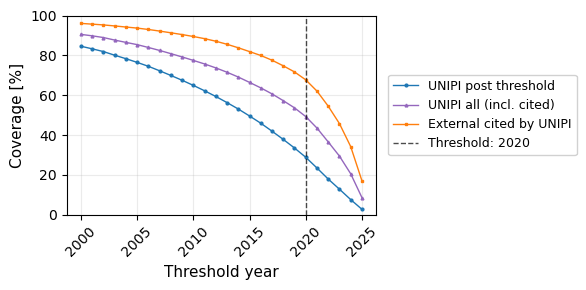


=== Threshold: 2020 ===
UNIPI post 2020     : 36809  (  28.9% of total UNIPI)
UNIPI all (incl. cited)  : 62862  (  49.3% of total UNIPI)
External cited by UNIPI  : 1540922  (  67.7% of total external)


In [6]:
plot_connected_elements_by_year(metrics, highlight_year=2020)

In [7]:
def get_unipi_and_external_nodes(
    G: nx.DiGraph,
    year_threshold: int,
) -> tuple[set, set, set, set]:
    """
    Partitions graph nodes into UNIPI categories and external nodes.
    UNIPI nodes without a valid publicationDate are included as parents
    if cited by a recent node.

    Returns:
        (surviving_unipi, external_nodes, recent_unipi, parent_unipi)
    """
    unipi_by_year: dict[str, int] = {}
    unipi_no_year: set[str]       = set()
    all_external:  set[str]       = set()

    for node, attrs in G.nodes(data=True):
        if attrs.get('is_unipi'):
            year = _extract_year(attrs.get('publicationDate'))
            if year is not None:
                unipi_by_year[node] = year
            else:
                unipi_no_year.add(node)
        else:
            all_external.add(node)

    recent_unipi = {n for n, yr in unipi_by_year.items() if yr >= year_threshold}

    parent_unipi = {
        cited
        for n in recent_unipi
        for cited in G.successors(n)
        if (cited in unipi_by_year and unipi_by_year[cited] < year_threshold)
        or cited in unipi_no_year
    }

    surviving_unipi = recent_unipi | parent_unipi

    external_nodes = {
        nb
        for n in surviving_unipi
        for nb in G.successors(n)
        if nb in all_external
    }

    return surviving_unipi, external_nodes, recent_unipi, parent_unipi


YEAR_THRESHOLD = 2020

surviving_unipi, external_nodes, recent_unipi, parent_unipi = \
    get_unipi_and_external_nodes(G, YEAR_THRESHOLD)

print(f"Year threshold  : {YEAR_THRESHOLD}")
print(f"Surviving UNIPI : {len(surviving_unipi)}")
print(f"  recent        : {len(recent_unipi)}")
print(f"  parent        : {len(parent_unipi)}")
print(f"External nodes  : {len(external_nodes)}")

Year threshold  : 2020
Surviving UNIPI : 62862
  recent        : 36809
  parent        : 26053
External nodes  : 1540922


In [8]:
def build_internal_graph(G: nx.DiGraph, surviving_unipi: set) -> nx.DiGraph:
    """Directed citation subgraph restricted to surviving UNIPI nodes."""
    G_internal = G.subgraph(surviving_unipi).copy()

    n_isolated = len(list(nx.isolates(G_internal)))
    print(f"G_internal — before: {G_internal.number_of_nodes()} nodes, {G_internal.number_of_edges()} edges, {n_isolated} isolated")
    G_internal.remove_nodes_from(list(nx.isolates(G_internal)))
    print(f"G_internal — after : {G_internal.number_of_nodes()} nodes, {G_internal.number_of_edges()} edges")

    return G_internal


def build_full_graph(
    G: nx.DiGraph,
    surviving_unipi: set,
    external_nodes: set,
) -> nx.DiGraph:
    """
    Directed citation subgraph including surviving UNIPI and connected
    external nodes. Isolated nodes are removed before returning.
    """
    G_full = G.subgraph(surviving_unipi | external_nodes).copy()

    n_isolated = len(list(nx.isolates(G_full)))
    print(f"G_full     — before: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges, {n_isolated} isolated")
    G_full.remove_nodes_from(list(nx.isolates(G_full)))
    print(f"G_full     — after : {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

    return G_full

In [9]:
G_internal = build_internal_graph(G, surviving_unipi)
G_full     = build_full_graph(G, surviving_unipi, external_nodes)

print(f"Internal : {G_internal.number_of_nodes()} nodes, {G_internal.number_of_edges()} edges")
print(f"Full     : {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

G_internal — before: 62862 nodes, 217925 edges, 7784 isolated
G_internal — after : 55078 nodes, 217925 edges
G_full     — before: 1603784 nodes, 2694706 edges, 2 isolated
G_full     — after : 1603782 nodes, 2694706 edges
Internal : 55078 nodes, 217925 edges
Full     : 1603782 nodes, 2694706 edges


## Bibliographic Coupling (BC) analysis

**Bibliographic Coupling**: two UNIPI nodes A and B are coupled if they both cite
the same external node C. The strength is measured by Jaccard similarity:

```
BC(A,B) = |ext(A) ∩ ext(B)| / |ext(A) ∪ ext(B)|
```

**Why not co-citation?** Co-citation measures similarity based on being cited
together by a third paper — it requires the cited papers to already be well-known.
BC is forward-looking and works on recent papers too.

**Why not direct citation alone?** Direct citation captures explicit interactions
but misses thematic proximity between groups that don't cite each other yet.
BC adds the latent thematic signal.

In [10]:
ext_citations: dict[str, set] = {
    n: {nb for nb in G.successors(n) if nb in external_nodes}
    for n in surviving_unipi
}

inverted: dict[str, list] = defaultdict(list)
for n, exts in ext_citations.items():
    for ext in exts:
        inverted[ext].append(n)

hub_sizes     = np.array([len(v) for v in inverted.values()])
ext_cit_sizes = np.array([len(s) for s in ext_citations.values()])
total         = len(surviving_unipi)
pct           = lambda n: 100 * n / total if total else 0.0

print("=== External hub diagnostics ===")
print(f"  Total external nodes reached        : {len(inverted)}")
print(f"  External cited by >= 2 UNIPI        : {(hub_sizes >= 2).sum()}  (potential BC pairs)")
print(f"  External cited by > 100 UNIPI       : {(hub_sizes > 100).sum()}")
print(f"  External cited by > 500 UNIPI       : {(hub_sizes > 500).sum()}")
print(f"  Hub size — max / p99 / p90 / median : "
      f"{hub_sizes.max()} / {int(np.percentile(hub_sizes, 99))} / "
      f"{int(np.percentile(hub_sizes, 90))} / {int(np.median(hub_sizes))}")

print("\n=== UNIPI external citation coverage ===")
print(f"  No external citations               : {(ext_cit_sizes == 0).sum():>5}  ({pct((ext_cit_sizes == 0).sum()):.1f}%)")
print(f"  Only 1 external cited               : {(ext_cit_sizes == 1).sum():>5}  ({pct((ext_cit_sizes == 1).sum()):.1f}%)")
print(f"  2+ external cited (BC-eligible)     : {(ext_cit_sizes >= 2).sum():>5}  ({pct((ext_cit_sizes >= 2).sum()):.1f}%)")
print(f"  Ext citations — mean / median / max : "
      f"{ext_cit_sizes.mean():.1f} / {int(np.median(ext_cit_sizes))} / {ext_cit_sizes.max()}")

print("\n=== Isolation by UNIPI category ===")
iso_recent = sum(1 for n in recent_unipi if not ext_citations[n])
iso_parent = sum(1 for n in parent_unipi if not ext_citations[n])
print(f"  Isolated — recent                   : {iso_recent:>5}  ({pct(iso_recent):.1f}%)")
print(f"  Isolated — parent                   : {iso_parent:>5}  ({pct(iso_parent):.1f}%)")

=== External hub diagnostics ===
  Total external nodes reached        : 1540922
  External cited by >= 2 UNIPI        : 379965  (potential BC pairs)
  External cited by > 100 UNIPI       : 160
  External cited by > 500 UNIPI       : 14
  Hub size — max / p99 / p90 / median : 1532 / 9 / 3 / 1

=== UNIPI external citation coverage ===
  No external citations               :  2007  (3.2%)
  Only 1 external cited               :  1084  (1.7%)
  2+ external cited (BC-eligible)     : 59771  (95.1%)
  Ext citations — mean / median / max : 39.4 / 30 / 4090

=== Isolation by UNIPI category ===
  Isolated — recent                   :   829  (1.3%)
  Isolated — parent                   :  1178  (1.9%)


This cell runs the complete bibliographic coupling sensitivity analysis in a single pass. It sweeps both dimensions simultaneously — MAX_HUB cap and Jaccard threshold — to produce the empirical evidence needed to lock in both parameters. Three figures are produced: a joint heatmap showing edge counts and discontinuities across the full parameter grid, a Jaccard value distribution for the chosen MAX_HUB, and a graph metrics panel (edges, isolated nodes, average degree) for the fine-grained Jaccard sweep.


In [11]:
from itertools import combinations
from collections import Counter

MAX_HUB_VALUES = [200, 300, 400, 500, 600, 700, 800, 900, 1000]
JACCARD_FINE = [round(x, 2) for x in np.arange(0.02, 0.11, 0.01)]
FIXED_MAX_HUB  = 800
MIN_BC_REF     = 0.05
n_unipi        = len(surviving_unipi)



# COMPUTATION  —  run once, reuse for all plots


def _bc_pairs(
    inverted: dict,
    ext_citations: dict,
    max_hub: int | None,
) -> dict[tuple, float]:
    co_counts: Counter = Counter()
    for unipi_list in inverted.values():
        k = len(unipi_list)
        if k < 2 or (max_hub is not None and k > max_hub):
            continue
        for u, v in combinations(unipi_list, 2):
            co_counts[min(u, v), max(u, v)] += 1

    return {
        (u, v): shared / len(ext_citations[u] | ext_citations[v])
        for (u, v), shared in co_counts.items()
        if ext_citations[u] | ext_citations[v]
    }


def _threshold_stats(pair_jaccards: dict, jt: float, n_unipi: int) -> dict:
    edges  = {(u, v) for (u, v), j in pair_jaccards.items() if j >= jt}
    degree = Counter(n for e in edges for n in e)
    degs   = list(degree.values()) if degree else [0]
    
    # Average degree locale: media tra i nodi connessi (con grado > 0)
    avg_deg_local = float(np.mean(degs))
    
    # Average degree totale: media considerando anche i nodi isolati (grado = 0)
    total_degree_sum = sum(degree.values())
    avg_deg_total = total_degree_sum / n_unipi if n_unipi > 0 else 0.0
    
    return {
        'jt'         : jt,
        'edges'      : len(edges),
        'isolated'   : n_unipi - len(degree),
        'avg_deg'    : avg_deg_local,      # media nodi connessi
        'avg_deg_tot': avg_deg_total,      # media tutti i nodi
        'max_deg'    : int(np.max(degs)),
    }


def compute_sensitivity_data(inverted, ext_citations):
    """
    Runs all sensitivity computations and returns a dict of raw results.
    Call this once; pass the result to the plot functions below.

    Returns
    -------
    dict with keys:
        edge_matrix         : np.ndarray  shape (len(MAX_HUB_VALUES), len(JACCARD_FINE))
        pair_jaccards_fixed : dict        Jaccard values at FIXED_MAX_HUB
        jt_results          : list[dict]  per-threshold stats at FIXED_MAX_HUB
        j_vals_fixed        : list[float] raw Jaccard values at FIXED_MAX_HUB
        hub_incr            : np.ndarray  % edge increase per MAX_HUB step
        step_labels         : list[str]
        disc_row            : int         heatmap row index of the FIXED_MAX_HUB discontinuity
    """
    print(f"{'MAX_HUB':<8}  {'pairs':<12}"
          + ''.join(f"  edges(j>={jt})" for jt in JACCARD_FINE))
    print("-" * 180)

    edge_matrix = np.zeros((len(MAX_HUB_VALUES), len(JACCARD_FINE)), dtype=float)

    for i, max_hub in enumerate(MAX_HUB_VALUES):
        pj          = _bc_pairs(inverted, ext_citations, max_hub)
        edge_counts = [sum(1 for j in pj.values() if j >= jt) for jt in JACCARD_FINE]
        edge_matrix[i] = edge_counts
        print(f"{str(max_hub):<8}  {len(pj):<12}"
              + ''.join(f"  {c:<14}" for c in edge_counts))

    print("\nDone.")

    # Fine Jaccard sweep at fixed MAX_HUB
    pair_jaccards_fixed = _bc_pairs(inverted, ext_citations, FIXED_MAX_HUB)
    j_vals_fixed        = list(pair_jaccards_fixed.values())
    jt_results          = [
        _threshold_stats(pair_jaccards_fixed, jt, n_unipi)
        for jt in JACCARD_FINE
    ]

    print(f"\n{'jt':<6} {'edges':<10} {'isolated':<10} {'avg_deg':<9} {'avg_deg_tot':<11} {'max_deg':<9}")
    print("-" * 60)
    for r in jt_results:
        print(f"{r['jt']:<6} {r['edges']:<10} {r['isolated']:<10} "
              f"{r['avg_deg']:<9.1f} {r['avg_deg_tot']:<11.2f} {r['max_deg']:<9}")

    # % edge increase per MAX_HUB step
    n = len(MAX_HUB_VALUES)
    hub_incr = np.zeros((n - 1, len(JACCARD_FINE)))
    for i in range(1, n):
        prev = edge_matrix[i - 1]
        curr = edge_matrix[i]
        hub_incr[i - 1] = np.where(prev > 0, (curr - prev) / prev * 100, 0.0)

    step_labels = [
        f"{MAX_HUB_VALUES[i - 1]}→{MAX_HUB_VALUES[i]}"
        for i in range(1, n)
    ]

    disc_idx = next(i for i, v in enumerate(MAX_HUB_VALUES) if v > FIXED_MAX_HUB)
    disc_row = disc_idx - 1

    return dict(
        edge_matrix         = edge_matrix,
        pair_jaccards_fixed = pair_jaccards_fixed,
        jt_results          = jt_results,
        j_vals_fixed        = j_vals_fixed,
        hub_incr            = hub_incr,
        step_labels         = step_labels,
        disc_row            = disc_row,
    )

In [12]:
sensitivity_data = compute_sensitivity_data(inverted, ext_citations)

MAX_HUB   pairs         edges(j>=0.02)  edges(j>=0.03)  edges(j>=0.04)  edges(j>=0.05)  edges(j>=0.06)  edges(j>=0.07)  edges(j>=0.08)  edges(j>=0.09)  edges(j>=0.1)
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
200       2459025       789331          466826          319746          232342          174015          135648          108696          87653           72992         
300       2720639       888393          533899          368647          268550          201200          156131          124589          100000          82804         
400       2989060       1067390         682662          495220          379021          298159          240994          196995          159595          131719        
500       3002928       1081122         694184          504554          386213          303757          245405          200553          162571          

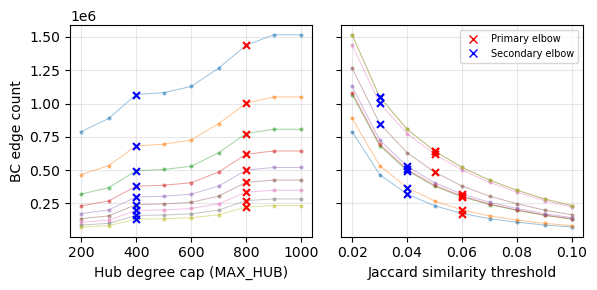

In [17]:
from matplotlib.lines import Line2D
import numpy as np

def find_top2_elbows(x, y):
    x, y = np.array(x), np.array(y)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    line_vec = (p2 - p1) / np.linalg.norm(p2 - p1)
    diff = np.stack([x, y], axis=1) - p1
    dists = np.abs(line_vec[0] * diff[:, 1] - line_vec[1] * diff[:, 0])
    dists[0] = dists[-1] = 0
    idx1 = np.argmax(dists)
    dists_tmp = dists.copy()
    dists_tmp[max(0, idx1-1):min(len(dists), idx1+2)] = 0
    idx2 = np.argmax(dists_tmp)
    return sorted([(idx1, x[idx1], y[idx1]), (idx2, x[idx2], y[idx2])], key=lambda t: t[0])

edge_matrix = sensitivity_data['edge_matrix']
fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

# --- Left: edge count vs max_hub, one curve per Jaccard threshold ---
for j_idx, jt in enumerate(JACCARD_FINE):
    y = edge_matrix[:, j_idx]
    elbows = find_top2_elbows(MAX_HUB_VALUES, y)
    axes[0].plot(MAX_HUB_VALUES, y, marker='o', markersize=2, linewidth=0.7,
                 color=f'C{j_idx}', alpha=0.45)
    ei = [e[0] for e in elbows]
    if len(ei) > 1:
        axes[0].scatter(MAX_HUB_VALUES[ei[1]], y[ei[1]], color='red',
                        marker='x', s=25, zorder=5)
        axes[0].scatter(MAX_HUB_VALUES[ei[0]], y[ei[0]], color='blue',
                        marker='x', s=25, zorder=5)

axes[0].set_xlabel('Hub degree cap (MAX_HUB)')
axes[0].set_ylabel('BC edge count')
axes[0].grid(True, alpha=0.3)

# --- Right: edge count vs Jaccard threshold, one curve per max_hub ---
for i, max_hub in enumerate(MAX_HUB_VALUES):
    y = edge_matrix[i, :]
    elbows = find_top2_elbows(JACCARD_FINE, y)
    axes[1].plot(JACCARD_FINE, y, marker='o', markersize=2, linewidth=0.7,
                 color=f'C{i}', alpha=0.45)
    ei = [e[0] for e in elbows]
    if len(ei) > 1:
        axes[1].scatter(JACCARD_FINE[ei[1]], y[ei[1]], color='red',
                        marker='x', s=25, zorder=5)
        axes[1].scatter(JACCARD_FINE[ei[0]], y[ei[0]], color='blue',
                        marker='x', s=25, zorder=5)

axes[1].set_xlabel('Jaccard similarity threshold')
axes[1].grid(True, alpha=0.3)

# --- Legend inside right plot ---
legend_handles = [
    Line2D([0], [0], color='red', marker='x', linestyle='None', markersize=6, label='Primary elbow'),
    Line2D([0], [0], color='blue', marker='x', linestyle='None', markersize=6, label='Secondary elbow'),
]
axes[1].legend(handles=legend_handles, loc='upper right', fontsize=7, framealpha=0.8)

plt.tight_layout()
plt.show()
fig.savefig('./output/A_sensitivity_elbow.pdf', bbox_inches='tight', dpi=300)

In [35]:
# ── BC_P99: fixed normalisation baseline (no hub cap, full pair set) ──────────
# Computed once and reused across all graph variants to ensure comparability.
shared_counts_baseline: Counter = Counter()
for unipi_list in inverted.values():
    if len(unipi_list) < 2:
        continue
    for u, v in combinations(unipi_list, 2):
        shared_counts_baseline[min(u, v), max(u, v)] += 1

bc_values_baseline = [
    n_shared / len(union)
    for (u, v), n_shared in shared_counts_baseline.items()
    if (union := ext_citations[u] | ext_citations[v])
]

BC_P99: float = float(np.percentile(bc_values_baseline, 99)) if bc_values_baseline else 1.0
print(f"BC 99th percentile (fixed normalisation): {BC_P99:.4f}")


# ── Helpers ───────────────────────────────────────────────────────────────────

def _compute_bc_raw(
    ext_cit: dict[str, set],
    inverted: dict[str, list],
    max_hub: int | None,
    min_bc: float,
    min_shared: int,
) -> dict[tuple, float]:
    """
    Computes raw Bibliographic Coupling (Jaccard) for all UNIPI pairs
    that share at least min_shared external citations, excluding hubs
    cited by more than max_hub UNIPI nodes.
    """
    shared_counts: Counter = Counter()
    for unipi_list in inverted.values():
        k = len(unipi_list)
        if k < 2 or (max_hub is not None and k > max_hub):
            continue
        for u, v in combinations(unipi_list, 2):
            shared_counts[min(u, v), max(u, v)] += 1

    bc_raw: dict[tuple, float] = {}
    for (u, v), n_shared in shared_counts.items():
        if n_shared < min_shared:
            continue
        union = ext_cit[u] | ext_cit[v]
        if not union:
            continue
        bc = n_shared / len(union)
        if bc >= min_bc:
            bc_raw[u, v] = bc

    return bc_raw


def _edge_attrs(
    is_direct: int,
    bc_val: float,
    bc_p99: float,
    alpha: float,
) -> dict:
    """Returns the full attribute dict for a combined graph edge."""
    bc_norm = min(bc_val / bc_p99, 1.0) if bc_p99 > 0 else 0.0
    return {
        'is_direct': is_direct,
        'bc'       : bc_val,
        'bc_norm'  : bc_norm,
        'weight'   : alpha * is_direct + (1 - alpha) * bc_norm,
    }


def build_combined_graph(
    G: nx.DiGraph,
    surviving_unipi: set,
    ext_cit: dict[str, set],
    inverted: dict[str, list],
    bc_p99: float,
    alpha: float = 0.5,
    max_hub: int | None = 300,
    min_bc: float = 0.03,
    min_shared: int = 2,
) -> nx.Graph:
    """
    Builds a single undirected weighted graph combining direct citation
    and Bibliographic Coupling (BC) for community detection.

    Edge weight formula
    -------------------
        weight(u,v) = alpha * is_direct(u,v) + (1 - alpha) * BC_norm(u,v)

    where:
        is_direct = 1 if u→v or v→u exists in G, else 0
        BC_norm   = BC(u,v) / bc_p99, clipped to [0, 1]

    ext_cit and inverted are passed in from the caller to avoid recomputation
    and guarantee consistency with the rest of the pipeline.
    BC_P99 is computed on the full pair set (no hub cap) and passed in as a
    fixed normalisation constant, ensuring comparability across graph variants.

    Args:
        G               : Full directed citation graph.
        surviving_unipi : Recent UNIPI nodes and their cited parents.
        ext_cit         : Precomputed external citations per UNIPI node.
        inverted        : Precomputed inverted index (external → UNIPI list).
        bc_p99          : 99th-percentile BC for normalisation (fixed baseline).
        alpha           : Weight of direct citation vs BC signal.
        max_hub         : Hub cap — externals cited by more than this are excluded.
        min_bc          : Minimum Jaccard BC to retain a BC edge.
        min_shared      : Minimum shared external citations for a BC edge.

    Returns:
        G_comb : Undirected weighted graph over surviving_unipi nodes.

    Edge attributes
    ---------------
        'weight'    (float): combined weight
        'is_direct' (int)  : 1 if a direct citation exists
        'bc'        (float): raw Jaccard BC value (0 if no BC edge)
        'bc_norm'   (float): normalised BC value
    """
    # ── Step 1: BC pairs ──────────────────────────────────────────────────────
    bc_raw = _compute_bc_raw(ext_cit, inverted, max_hub, min_bc, min_shared)

    # ── Step 2: initialise graph with all surviving UNIPI nodes ──────────────
    G_comb = nx.Graph()
    G_comb.add_nodes_from((n, G.nodes[n]) for n in surviving_unipi)

    # ── Step 3: direct citation edges (UNIPI → UNIPI only) ───────────────────
    for n in surviving_unipi:
        for succ in G.successors(n):
            if succ not in surviving_unipi or G_comb.has_edge(n, succ):
                continue
            key = min(n, succ), max(n, succ)
            G_comb.add_edge(n, succ, **_edge_attrs(1, bc_raw.get(key, 0.0), bc_p99, alpha))

    # ── Step 4: BC edges (add new; update weight on existing direct edges) ────
    for (u, v), bc_val in bc_raw.items():
        if G_comb.has_edge(u, v):
            # Direct edge already exists — enrich with BC signal
            G_comb[u][v].update(_edge_attrs(G_comb[u][v]['is_direct'], bc_val, bc_p99, alpha))
        else:
            G_comb.add_edge(u, v, **_edge_attrs(0, bc_val, bc_p99, alpha))
    G_comb.remove_nodes_from(list(nx.isolates(G_comb)))
    return G_comb


BC 99th percentile (fixed normalisation): 0.2054


In [36]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
MAX_HUB    = 800   # last clean step before edge count discontinuity
MIN_BC     = 0.05  # null model confirmed all BC signal is statistically real
MIN_SHARED = 2     # excludes pairs sharing only a single external reference
# ─────────────────────────────────────────────────────────────────────────────

## Sensitivity su alpha

**Obiettivo**: verificare che le community trovate siano stabili al variare di alpha.
Se NMI tra community a alpha diversi è > 0.85, allora la scelta specifica di alpha
non cambia i risultati in modo sostanziale — il parametro è giustificato empiricamente.

Se NMI scende molto, alpha è critico e va motivato con più cura.

This cell runs the alpha sensitivity analysis for community detection. Louvain is applied to a freshly built combined graph for each candidate value of alpha, and the resulting partitions are compared pairwise using Normalised Mutual Information (NMI) — a score of 1 meaning two partitions are identical, 0 meaning they share no structure. If the NMI matrix shows high values across a broad range of alpha, the community structure is stable and the specific choice of alpha is immaterial; sharp drops reveal regions where the balance between direct citation and BC signal genuinely changes the partition. Modularity and community count are plotted alongside to give a complementary view of partition quality.

In [41]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from cdlib import algorithms
from sklearn.metrics import normalized_mutual_info_score



# ALGORITMO — Infomap


def run_infomap(G_nx: nx.Graph, directed: bool = False, weighted: bool = True) -> tuple[dict, int]:
    """
    Esegue Infomap su un grafo NetworkX.

    Args:
        G_nx     : Grafo NetworkX.
        directed : Se True, rispetta la direzione degli archi.
        weighted : Se True, usa i pesi degli archi. Se False, li rimuove.

    Returns:
        partition     : dict nodo → id comunità.
        n_communities : Numero di comunità trovate.
    """
    if not weighted:
        G_nx = G_nx.copy()
        for u, v in G_nx.edges():
            G_nx[u][v].pop("weight", None)

    if directed:
        result = algorithms.infomap(G_nx, flags="--directed")
    else:
        result = algorithms.infomap(G_nx)

    partition = {
        node: i
        for i, comm in enumerate(result.communities)
        for node in comm
    }
    n_communities = len(result.communities)

    return partition, n_communities

import os
import networkx as nx
import matplotlib.pyplot as plt
from cdlib import algorithms
from sklearn.metrics import normalized_mutual_info_score
from networkx.algorithms.community import modularity

# ...def run_infomap come sopra...

ALPHA_VALUES = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]

def compute_alpha_sensitivity(
    G,
    G_internal: nx.DiGraph,
    surviving_unipi,
    ext_citations,
    inverted,
    bc_p99,
    max_hub,
    min_bc,
    min_shared,
) -> dict:
    partition_dir, n_comm_dir = run_infomap(G_internal, directed=True, weighted=False)
    print(f"Baseline 1 (diretto,     non pesato): {n_comm_dir} comunità")

    G_internal_undir              = G_internal.to_undirected()
    partition_undir, n_comm_undir = run_infomap(G_internal_undir, directed=False, weighted=False)
    print(f"Baseline 2 (non diretto, non pesato): {n_comm_undir} comunità\n")

    results_by_alpha = {}
    n_comms          = []
    nmi_scores_dir   = []
    nmi_scores_undir = []
    modularities     = []

    for alpha in ALPHA_VALUES:
        G_tmp = build_combined_graph(
            G, surviving_unipi,
            ext_cit=ext_citations,
            inverted=inverted,
            bc_p99=bc_p99,
            alpha=alpha,
            max_hub=max_hub,
            min_bc=min_bc,
            min_shared=min_shared,
        )
        G_tmp.remove_nodes_from([n for n, d in G_tmp.degree() if d == 0])

        partition_alpha, n_comm = run_infomap(G_tmp, directed=False, weighted=True)

        # NMI vs baseline 1 (diretto)
        common_dir = set(partition_dir.keys()) & set(partition_alpha.keys())
        nmi_dir = normalized_mutual_info_score(
            [partition_dir[n]   for n in common_dir],
            [partition_alpha[n] for n in common_dir],
        ) if len(common_dir) > 0 else 0.0

        # NMI vs baseline 2 (non diretto)
        common_undir = set(partition_undir.keys()) & set(partition_alpha.keys())
        nmi_undir = normalized_mutual_info_score(
            [partition_undir[n] for n in common_undir],
            [partition_alpha[n] for n in common_undir],
        ) if len(common_undir) > 0 else 0.0

        # Calcolo modularità
        communities = [set([n for n, c in partition_alpha.items() if c == i]) for i in set(partition_alpha.values())]
        Q = modularity(G_tmp, communities)
        modularities.append(Q)

        results_by_alpha[alpha] = {
            "comm":      partition_alpha,
            "n_comm":    n_comm,
            "nmi_dir":   nmi_dir,
            "nmi_undir": nmi_undir,
            "modularity": Q,
        }
        n_comms.append(n_comm)
        nmi_scores_dir.append(nmi_dir)
        nmi_scores_undir.append(nmi_undir)

        print(
            f"alpha={alpha:.2f}  |  {n_comm:3d} comunità  |  "
            f"NMI vs diretto={nmi_dir:.4f}  |  NMI vs non diretto={nmi_undir:.4f}  |  Q={Q:.3f}"
        )

    return dict(
        partition_dir=partition_dir,
        partition_undir=partition_undir,
        n_comm_dir=n_comm_dir,
        n_comm_undir=n_comm_undir,
        results_by_alpha=results_by_alpha,
        n_comms=n_comms,
        nmi_scores_dir=nmi_scores_dir,
        nmi_scores_undir=nmi_scores_undir,
        modularities=modularities,
    )

def plot_alpha_sensitivity(
    data: dict,
    out_dir: str,
    figsize: tuple = (16, 4),
) -> None:
    os.makedirs(out_dir, exist_ok=True)

    n_comms          = data['n_comms']
    nmi_scores_dir   = data['nmi_scores_dir']
    modularities     = data['modularities']
    n_comm_dir       = data['n_comm_dir']
    n_comm_undir     = data['n_comm_undir']

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Numero comunità
    axes[0].plot(ALPHA_VALUES, n_comms, marker='o', markersize=5,
                 color='tab:blue', linewidth=1.5, label='Infomap pesato')
    axes[0].axhline(n_comm_dir,   color='tab:orange', linewidth=1,
                    linestyle='--', label=f'Baseline diretto ({n_comm_dir} comm.)')
    axes[0].axhline(n_comm_undir, color='tab:green',  linewidth=1,
                    linestyle='--', label=f'Baseline non diretto ({n_comm_undir} comm.)')
    axes[0].set_xlabel('alpha',      fontsize=11)
    axes[0].set_ylabel('# comunità', fontsize=11)
    axes[0].set_title('Comunità al variare di alpha', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.25)

    # NMI vs baseline diretto
    axes[1].plot(ALPHA_VALUES, nmi_scores_dir, marker='o', markersize=5,
                 color='tab:orange', linewidth=1.5, label='NMI vs baseline diretto')
    axes[1].axhline(1.0, color='tab:gray', linewidth=1,
                    linestyle='--', label='Accordo perfetto (NMI=1)')
    axes[1].set_xlabel('alpha', fontsize=11)
    axes[1].set_ylabel('NMI',   fontsize=11)
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title('NMI vs grafo diretto', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.25)

    # Modularity
    axes[2].plot(ALPHA_VALUES, modularities, marker='o', markersize=5,
                 color='tab:purple', linewidth=1.5, label='Modularity')
    axes[2].set_xlabel('alpha', fontsize=11)
    axes[2].set_ylabel('Modularity Q', fontsize=11)
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title('Modularità delle comunità', fontsize=12, fontweight='bold')
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.25)

    plt.tight_layout()
    path = os.path.join(out_dir, "sensitivity_alpha_infomap_nmi_modularity.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Salvato: {path}")

In [42]:
# Quante componenti debolmente connesse ha G_internal?
wcc = list(nx.weakly_connected_components(G_internal))
print(f"Componenti deboli: {len(wcc)}")
print(f"Dimensione maggiore: {max(len(c) for c in wcc)}")
print(f"Componenti di dimensione 1: {sum(1 for c in wcc if len(c) == 1)}")
print(f"Componenti di dimensione 2: {sum(1 for c in wcc if len(c) == 2)}")

# Distribuzione out-degree
out_degrees = [d for _, d in G_internal.out_degree()]
print(f"Nodi out-degree 0: {sum(1 for d in out_degrees if d == 0)}")
print(f"Nodi out-degree 1: {sum(1 for d in out_degrees if d == 1)}")
print(f"Media out-degree: {np.mean(out_degrees):.2f}")

Componenti deboli: 1488
Dimensione maggiore: 49243
Componenti di dimensione 1: 0
Componenti di dimensione 2: 857
Nodi out-degree 0: 9959
Nodi out-degree 1: 10398
Media out-degree: 3.96


In [44]:
# ── BC_P99: fixed normalisation baseline (no hub cap, full pair set) ──────────
# Computed once and reused across all graph variants to ensure comparability.
shared_counts_baseline: Counter = Counter()
for unipi_list in inverted.values():
    if len(unipi_list) < 2:
        continue
    for u, v in combinations(unipi_list, 2):
        shared_counts_baseline[min(u, v), max(u, v)] += 1

bc_values_baseline = [
    n_shared / len(union)
    for (u, v), n_shared in shared_counts_baseline.items()
    if (union := ext_citations[u] | ext_citations[v])
]

BC_P99: float = float(np.percentile(bc_values_baseline, 99)) if bc_values_baseline else 1.0
print(f"BC 99th percentile (fixed normalisation): {BC_P99:.4f}")


# ── Helpers ───────────────────────────────────────────────────────────────────

def _compute_bc_raw(
    ext_cit: dict[str, set],
    inverted: dict[str, list],
    max_hub: int | None,
    min_bc: float,
    min_shared: int,
) -> dict[tuple, float]:
    """
    Computes raw Bibliographic Coupling (Jaccard) for all UNIPI pairs
    that share at least min_shared external citations, excluding hubs
    cited by more than max_hub UNIPI nodes.
    """
    shared_counts: Counter = Counter()
    for unipi_list in inverted.values():
        k = len(unipi_list)
        if k < 2 or (max_hub is not None and k > max_hub):
            continue
        for u, v in combinations(unipi_list, 2):
            shared_counts[min(u, v), max(u, v)] += 1

    bc_raw: dict[tuple, float] = {}
    for (u, v), n_shared in shared_counts.items():
        if n_shared < min_shared:
            continue
        union = ext_cit[u] | ext_cit[v]
        if not union:
            continue
        bc = n_shared / len(union)
        if bc >= min_bc:
            bc_raw[u, v] = bc

    return bc_raw


def _edge_attrs(
    is_direct: int,
    bc_val: float,
    bc_p99: float,
    alpha: float,
) -> dict:
    """Returns the full attribute dict for a combined graph edge."""
    bc_norm = min(bc_val / bc_p99, 1.0) if bc_p99 > 0 else 0.0
    return {
        'is_direct': is_direct,
        'bc'       : bc_val,
        'bc_norm'  : bc_norm,
        'weight'   : alpha * is_direct + (1 - alpha) * bc_norm,
    }


def build_combined_graph(
    G: nx.DiGraph,
    surviving_unipi: set,
    ext_cit: dict[str, set],
    inverted: dict[str, list],
    bc_p99: float,
    alpha: float = 0.5,
    max_hub: int | None = 300,
    min_bc: float = 0.03,
    min_shared: int = 2,
) -> nx.Graph:
    """
    Builds a single undirected weighted graph combining direct citation
    and Bibliographic Coupling (BC) for community detection.

    Edge weight formula
    -------------------
        weight(u,v) = alpha * is_direct(u,v) + (1 - alpha) * BC_norm(u,v)

    where:
        is_direct = 1 if u→v or v→u exists in G, else 0
        BC_norm   = BC(u,v) / bc_p99, clipped to [0, 1]

    ext_cit and inverted are passed in from the caller to avoid recomputation
    and guarantee consistency with the rest of the pipeline.
    BC_P99 is computed on the full pair set (no hub cap) and passed in as a
    fixed normalisation constant, ensuring comparability across graph variants.

    Args:
        G               : Full directed citation graph.
        surviving_unipi : Recent UNIPI nodes and their cited parents.
        ext_cit         : Precomputed external citations per UNIPI node.
        inverted        : Precomputed inverted index (external → UNIPI list).
        bc_p99          : 99th-percentile BC for normalisation (fixed baseline).
        alpha           : Weight of direct citation vs BC signal.
        max_hub         : Hub cap — externals cited by more than this are excluded.
        min_bc          : Minimum Jaccard BC to retain a BC edge.
        min_shared      : Minimum shared external citations for a BC edge.

    Returns:
        G_comb : Undirected weighted graph over surviving_unipi nodes.

    Edge attributes
    ---------------
        'weight'    (float): combined weight
        'is_direct' (int)  : 1 if a direct citation exists
        'bc'        (float): raw Jaccard BC value (0 if no BC edge)
        'bc_norm'   (float): normalised BC value
    """
    # ── Step 1: BC pairs ──────────────────────────────────────────────────────
    bc_raw = _compute_bc_raw(ext_cit, inverted, max_hub, min_bc, min_shared)

    # ── Step 2: initialise graph with all surviving UNIPI nodes ──────────────
    G_comb = nx.Graph()
    G_comb.add_nodes_from((n, G.nodes[n]) for n in surviving_unipi)

    # ── Step 3: direct citation edges (UNIPI → UNIPI only) ───────────────────
    for n in surviving_unipi:
        for succ in G.successors(n):
            if succ not in surviving_unipi or G_comb.has_edge(n, succ):
                continue
            key = min(n, succ), max(n, succ)
            G_comb.add_edge(n, succ, **_edge_attrs(1, bc_raw.get(key, 0.0), bc_p99, alpha))

    # ── Step 4: BC edges (add new; update weight on existing direct edges) ────
    for (u, v), bc_val in bc_raw.items():
        if G_comb.has_edge(u, v):
            # Direct edge already exists — enrich with BC signal
            G_comb[u][v].update(_edge_attrs(G_comb[u][v]['is_direct'], bc_val, bc_p99, alpha))
        else:
            G_comb.add_edge(u, v, **_edge_attrs(0, bc_val, bc_p99, alpha))
    G_comb.remove_nodes_from(list(nx.isolates(G_comb)))
    return G_comb


BC 99th percentile (fixed normalisation): 0.2054


In [45]:
alpha_data = compute_alpha_sensitivity(
    G,
    G_internal,          # aggiunto — baseline per NMI
    surviving_unipi, ext_citations, inverted,
    bc_p99=BC_P99, max_hub=MAX_HUB, min_bc=MIN_BC, min_shared=MIN_SHARED,
)

Baseline 1 (diretto,     non pesato): 1498 comunità
Baseline 2 (non diretto, non pesato): 1495 comunità

alpha=0.10  |  1175 comunità  |  NMI vs diretto=0.7048  |  NMI vs non diretto=0.7900  |  Q=0.454
alpha=0.15  |  1176 comunità  |  NMI vs diretto=0.7080  |  NMI vs non diretto=0.7658  |  Q=0.487
alpha=0.20  |  1175 comunità  |  NMI vs diretto=0.7125  |  NMI vs non diretto=0.7710  |  Q=0.518
alpha=0.25  |  1175 comunità  |  NMI vs diretto=0.7235  |  NMI vs non diretto=0.8422  |  Q=0.541
alpha=0.30  |  1177 comunità  |  NMI vs diretto=0.7395  |  NMI vs non diretto=0.7961  |  Q=0.578
alpha=0.35  |  1173 comunità  |  NMI vs diretto=0.7188  |  NMI vs non diretto=0.8404  |  Q=0.592
alpha=0.40  |  1174 comunità  |  NMI vs diretto=0.7301  |  NMI vs non diretto=0.8393  |  Q=0.620
alpha=0.45  |  1173 comunità  |  NMI vs diretto=0.7109  |  NMI vs non diretto=0.8253  |  Q=0.641
alpha=0.50  |  1174 comunità  |  NMI vs diretto=0.7346  |  NMI vs non diretto=0.8510  |  Q=0.668
alpha=0.55  |  1172 co

In [46]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
ALPHA      = 0.35  # validated via sensitivity analysis in Section 8
# ─────────────────────────────────────────────────────────────────────────────

G_combined = build_combined_graph(
    G, surviving_unipi,
    ext_cit=ext_citations,
    inverted=inverted,
    bc_p99=BC_P99,
    alpha=ALPHA,
    max_hub=MAX_HUB,
    min_bc=MIN_BC,
    min_shared=MIN_SHARED,
)

# ── Edge composition breakdown ────────────────────────────────────────────────
edge_data = [(d['is_direct'], d['bc']) for _, _, d in G_combined.edges(data=True)]

n_direct  = sum(1 for is_d, bc in edge_data if is_d and bc == 0)
n_both    = sum(1 for is_d, bc in edge_data if is_d and bc > 0)
n_bc_only = sum(1 for is_d, bc in edge_data if not is_d)

print("Combined graph:")
print(f"  Nodes          : {G_combined.number_of_nodes()}")
print(f"  Total edges    : {G_combined.number_of_edges()}")
print(f"  Direct only    : {n_direct}")
print(f"  Direct + BC    : {n_both}")
print(f"  BC only        : {n_bc_only}")

Combined graph:
  Nodes          : 57603
  Total edges    : 745451
  Direct only    : 145030
  Direct + BC    : 72144
  BC only        : 528277


In [ ]:
import gzip

def save_graph(
    graph: nx.Graph | nx.DiGraph,
    name: str,
    out_dir: str,
    year_threshold: int,
    compress: bool = True,
) -> str:
    os.makedirs(out_dir, exist_ok=True)
    ext  = '.gpickle.gz' if compress else '.gpickle'
    path = os.path.join(out_dir, f"graph_{name}_{year_threshold}{ext}")

    opener = gzip.open if compress else open
    with opener(path, 'wb') as f:
        pickle.dump(graph, f, protocol=pickle.HIGHEST_PROTOCOL)

    size_mb = os.path.getsize(path) / 1e6
    print(f"  Saved {name:<20} → {path}  ({size_mb:.1f} MB)")
    return path


def load_graph(path: str) -> nx.Graph | nx.DiGraph:
    opener = gzip.open if path.endswith('.gz') else open
    with opener(path, 'rb') as f:
        return pickle.load(f)


def _graph_summary(graph: nx.Graph | nx.DiGraph, label: str) -> None:
    """Prints node, edge, and isolated-node statistics for a single graph."""
    n_nodes    = graph.number_of_nodes()
    n_edges    = graph.number_of_edges()
    n_isolated = sum(1 for _, d in graph.degree() if d == 0)
    iso_pct    = 100 * n_isolated / n_nodes if n_nodes else 0.0

    print(f"\n{label}:")
    print(f"  Nodes          : {n_nodes}")
    print(f"  Edges          : {n_edges}")
    print(f"  Isolated nodes : {n_isolated}  ({iso_pct:.2f}%)")


# ── Save graphs ───────────────────────────────────────────────────────────────
# Isolated nodes were already removed before community detection —
# each graph is cleaned independently since isolation status differs per graph.
print("=== Saving graphs ===")
for graph, name in [(G_internal, 'internal'), (G_full, 'full'), (G_combined, 'combined')]:
    save_graph(graph, name, OUT_GRAPH_DIR, YEAR_THRESHOLD)

# ── Final structural summary ──────────────────────────────────────────────────
print("\n=== Final graph statistics ===")
_graph_summary(G_combined, "G_combined (direct + BC, undirected)")
_graph_summary(G_internal, "G_internal (direct citations only)")
_graph_summary(G_full,     "G_full     (all citations + external)")

=== Saving graphs ===
  Saved internal             → /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/graph/graph_internal_2020.gpickle.gz  (36.7 MB)
  Saved full                 → /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/graph/graph_full_2020.gpickle.gz  (128.4 MB)
  Saved combined             → /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/data/graph/graph_combined_2020.gpickle.gz  (52.0 MB)

=== Final graph statistics ===

G_combined (direct + BC, undirected):
  Nodes          : 57603
  Edges          : 745451
  Isolated nodes : 0  (0.00%)

G_internal (direct citations only):
  Nodes          : 55078
  Edges          : 217925
  Isolated nodes : 0  (0.00%)

G_full     (all citations + external):
  Nodes          : 1603782
  Edges          : 2694706
  Isolated nodes : 0  (0.00%)
